Nodes: 3475, Edges: 8219


C:\Users\diego\AppData\Local\Temp\ipykernel_76980\1819492554.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  locations['lat'] = locations.geometry.centroid.y
C:\Users\diego\AppData\Local\Temp\ipykernel_76980\1819492554.py:23: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  locations['lon'] = locations.geometry.centroid.x


Restaurant locations:
          lat        lon
0   48.299706  14.291311
1   48.312988  14.282716
2   48.313991  14.281167
3   48.334765  14.321172
4   48.329202  14.320524
5   48.329568  14.319258
6   48.330183  14.324424
7   48.334591  14.321609
8   48.313179  14.286710
9   48.313014  14.282010
10  48.308940  14.282304
11  48.302943  14.283999
12  48.313173  14.284976
13  48.310823  14.281660
14  48.309219  14.282637
15  48.312401  14.287120
16  48.315192  14.277774
17  48.302962  14.290890
18  48.343826  14.274635
19  48.305667  14.282115


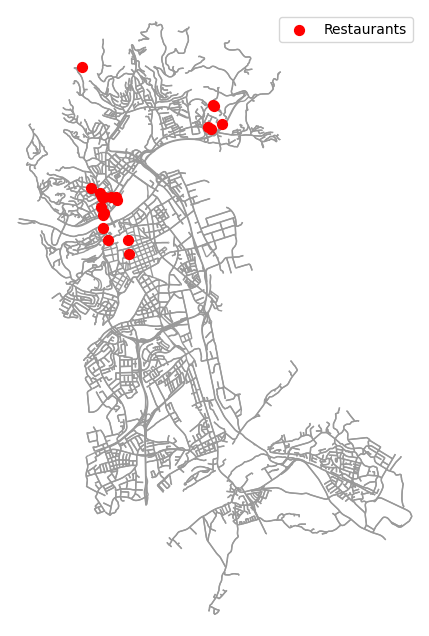

Unique graph nodes after snapping: 18
Distance matrix (meters):
              C0           C1           C2           C3           C4  \
C0      0.000000  3107.187002  3121.941773  7127.376354  6394.889246   
C1   2344.289259     0.000000   152.324010  4380.676191  3648.189083   
C2   2628.106505   289.375892     0.000000  4343.911450  3611.424342   
C3   6381.592388  4342.032467  4313.635967     0.000000   892.003208   
C4   5666.296897  3639.857849  3611.461350   882.167163     0.000000   
C5   5824.990724  3966.924593  3938.528093  1424.078237   665.190086   
C6   2429.923361   384.037256   536.361266  4270.514593  3538.027485   
C7   2413.073878    68.784619    83.539391  4427.450841  3694.963733   
C8   2388.869818   777.615557   792.370328  5100.321204  4367.834097   
C9   1542.825168  1930.847949  1945.602720  6238.011292  5505.524184   
C10  2398.025166   198.319271   350.643281  4436.200449  3703.713341   
C11  2186.185090   486.579246   501.334018  4845.245468  4112.758360   


In [5]:
# Single cell: Get real-world TSP data from OpenStreetMap (OSMnx >= 1.3)
import osmnx as ox
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Download road network ---
city = "Linz, Austria"
G = ox.graph_from_place(city, network_type='drive')
print(f"Nodes: {len(G.nodes)}, Edges: {len(G.edges)}")

# --- 2. Extract 20 Restaurants (POIs) ---
tags = {"amenity": "restaurant"}

# FIX 1: ox.geometries was removed in OSMnx >= 1.3; use ox.features instead
restaurants = ox.features.features_from_place(city, tags)
restaurants = restaurants.head(20).reset_index()

# FIX 2: Restaurants may have Polygon geometry (building footprints), not just Points.
# Use .centroid to safely extract a single lat/lon for any geometry type.
locations = restaurants[['geometry']].copy()
locations['lat'] = locations.geometry.centroid.y
locations['lon'] = locations.geometry.centroid.x

print("Restaurant locations:")
print(locations[['lat', 'lon']])

# --- 3. Visualize Graph + POIs ---
# FIX 3: plot_graph returns (fig, ax); add scatter to ax before plt.show()
fig, ax = ox.plot_graph(G, show=False, close=False, bgcolor='white', node_size=0)
ax.scatter(locations['lon'], locations['lat'], c='red', s=50, zorder=5, label='Restaurants')
ax.legend()
plt.show()

# --- 4. Map POIs to nearest graph nodes ---
nodes = [
    ox.distance.nearest_nodes(G, X=lon, Y=lat)
    for lon, lat in zip(locations['lon'], locations['lat'])
]

# FIX 4: Deduplicate nodes — two POIs may snap to the same graph node,
# which would create duplicate rows/cols in the distance matrix.
unique_nodes = list(dict.fromkeys(nodes))  # preserves order, removes duplicates
n = len(unique_nodes)
print(f"Unique graph nodes after snapping: {n}")

# --- 5. Compute Distance Matrix ---
INF = float('inf')
distance_matrix = [[0] * n for _ in range(n)]

for i in range(n):
    for j in range(n):
        if i != j:
            try:
                # FIX 5: shortest_path_length raises NetworkXNoPath if nodes are
                # disconnected. Fall back to INF so the matrix is always fully populated.
                distance_matrix[i][j] = nx.shortest_path_length(
                    G, unique_nodes[i], unique_nodes[j], weight='length'
                )
            except nx.NetworkXNoPath:
                distance_matrix[i][j] = INF
            except nx.NodeNotFound as e:
                print(f"  Warning: node not found ({e}), setting distance to INF")
                distance_matrix[i][j] = INF

distance_df = pd.DataFrame(
    distance_matrix,
    columns=[f"C{i}" for i in range(n)],
    index=[f"C{i}" for i in range(n)]
)
print("Distance matrix (meters):")
print(distance_df)

# --- 6. Save to CSV ---
distance_df.to_csv("linz_restaurant_distances.csv", index=True)
locations[['lat', 'lon']].to_csv("linz_restaurant_locations.csv", index=False)
print("Saved: linz_restaurant_distances.csv, linz_restaurant_locations.csv")

Gen    0 | Best distance: 35,015.4 m
Gen   50 | Best distance: 25,753.6 m
Gen  100 | Best distance: 25,753.6 m
Gen  150 | Best distance: 25,753.6 m
Gen  200 | Best distance: 25,753.6 m
Gen  250 | Best distance: 25,753.6 m
Gen  300 | Best distance: 25,753.6 m
Gen  350 | Best distance: 25,753.6 m
Gen  400 | Best distance: 25,753.6 m
Gen  450 | Best distance: 25,753.6 m

Running 2-opt local search on best route...
Final distance after 2-opt: 25,753.6 m  (25.75 km)


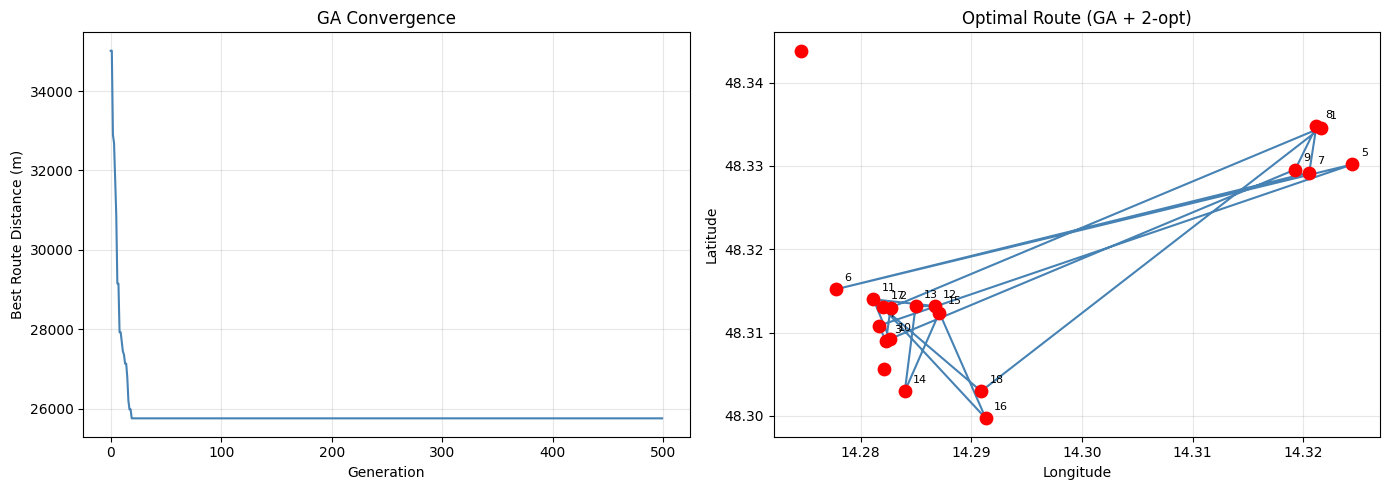


Optimal visit order:
  Stop  1: Restaurant 7  (48.33459, 14.32161)
  Stop  2: Restaurant 1  (48.31299, 14.28272)
  Stop  3: Restaurant 10  (48.30894, 14.28230)
  Stop  4: Restaurant 13  (48.31082, 14.28166)
  Stop  5: Restaurant 6  (48.33018, 14.32442)
  Stop  6: Restaurant 16  (48.31519, 14.27777)
  Stop  7: Restaurant 4  (48.32920, 14.32052)
  Stop  8: Restaurant 3  (48.33477, 14.32117)
  Stop  9: Restaurant 5  (48.32957, 14.31926)
  Stop 10: Restaurant 14  (48.30922, 14.28264)
  Stop 11: Restaurant 2  (48.31399, 14.28117)
  Stop 12: Restaurant 8  (48.31318, 14.28671)
  Stop 13: Restaurant 12  (48.31317, 14.28498)
  Stop 14: Restaurant 11  (48.30294, 14.28400)
  Stop 15: Restaurant 15  (48.31240, 14.28712)
  Stop 16: Restaurant 0  (48.29971, 14.29131)
  Stop 17: Restaurant 9  (48.31301, 14.28201)
  Stop 18: Restaurant 17  (48.30296, 14.29089)
  → Return to start: Restaurant 7


In [8]:
import random
import numpy as np
import matplotlib.pyplot as plt

# --- Load distance matrix (or use the one already in memory) ---
distance_df = pd.read_csv("linz_restaurant_distances.csv", index_col=0)

dist = distance_df.values.copy()
dist[dist == float('inf')] = 999999  # replace INF with large penalty
n = len(dist)

# ── GA Parameters ──────────────────────────────────────────────
POP_SIZE      = 200
GENERATIONS   = 500
ELITE_SIZE    = 20
MUTATION_RATE = 0.02
TOURNAMENT_K  = 5
SNAPSHOT_EVERY = 5
snapshots = []
# ── Helper functions ────────────────────────────────────────────
def route_distance(route):
    return sum(dist[route[i]][route[(i + 1) % n]] for i in range(n))

def initial_population(pop_size):
    base = list(range(n))
    return [random.sample(base, n) for _ in range(pop_size)]

def tournament_select(population, fitnesses):
    contestants = random.sample(list(zip(population, fitnesses)), TOURNAMENT_K)
    return min(contestants, key=lambda x: x[1])[0]

def ordered_crossover(p1, p2):
    """Order Crossover (OX) — preserves relative order of cities."""
    a, b = sorted(random.sample(range(n), 2))
    child = [None] * n
    child[a:b] = p1[a:b]
    fill = [x for x in p2 if x not in child]
    idx = 0
    for i in range(n):
        if child[i] is None:
            child[i] = fill[idx]
            idx += 1
    return child

def mutate(route):
    """Swap mutation."""
    route = route[:]
    if random.random() < MUTATION_RATE:
        i, j = random.sample(range(n), 2)
        route[i], route[j] = route[j], route[i]
    return route

def two_opt(route, max_iter=100):
    """Local search: 2-opt improvement pass."""
    best = route[:]
    best_dist = route_distance(best)
    for _ in range(max_iter):
        improved = False
        for i in range(1, n - 1):
            for j in range(i + 1, n):
                new = best[:i] + best[i:j+1][::-1] + best[j+1:]
                d = route_distance(new)
                if d < best_dist:
                    best, best_dist = new, d
                    improved = True
        if not improved:
            break
    return best

# ── Main GA loop ─────────────────────────────────────────────────
random.seed(42)
population = initial_population(POP_SIZE)
best_route = None
best_dist  = float('inf')
history    = []

for gen in range(GENERATIONS):
    fitnesses = [route_distance(r) for r in population]

    # Track best
    gen_best_idx = np.argmin(fitnesses)
    if fitnesses[gen_best_idx] < best_dist:
        best_dist  = fitnesses[gen_best_idx]
        best_route = population[gen_best_idx][:]

    history.append(best_dist)
    if gen % SNAPSHOT_EVERY == 0:
        snapshots.append((gen, best_route[:], best_dist))
    # Elitism: carry top individuals forward
    elite_idx  = np.argsort(fitnesses)[:ELITE_SIZE]
    new_pop    = [population[i] for i in elite_idx]

    # Fill rest of population
    while len(new_pop) < POP_SIZE:
        p1 = tournament_select(population, fitnesses)
        p2 = tournament_select(population, fitnesses)
        child = ordered_crossover(p1, p2)
        child = mutate(child)
        new_pop.append(child)

    population = new_pop

    if gen % 50 == 0:
        print(f"Gen {gen:4d} | Best distance: {best_dist:,.1f} m")

# Final 2-opt polish on the best route
print("\nRunning 2-opt local search on best route...")
best_route = two_opt(best_route)
best_dist  = route_distance(best_route)
print(f"Final distance after 2-opt: {best_dist:,.1f} m  ({best_dist/1000:.2f} km)")
snapshots.append((GENERATIONS, best_route[:], best_dist))
# ── Plot 1: Convergence curve ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history, color='steelblue', linewidth=1.5)
axes[0].set_title("GA Convergence")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Best Route Distance (m)")
axes[0].grid(True, alpha=0.3)

# ── Plot 2: Optimal route on map ──────────────────────────────────
lats = locations['lat'].values
lons = locations['lon'].values

ordered_lons = [lons[i] for i in best_route] + [lons[best_route[0]]]
ordered_lats = [lats[i] for i in best_route] + [lats[best_route[0]]]

axes[1].plot(ordered_lons, ordered_lats, 'o-', color='steelblue',
             markersize=8, linewidth=1.5, zorder=3)
axes[1].scatter(lons, lats, c='red', s=80, zorder=4)

# Label each stop
for i, idx in enumerate(best_route):
    axes[1].annotate(str(i + 1), (lons[idx], lats[idx]),
                     textcoords="offset points", xytext=(6, 6), fontsize=8)

axes[1].set_title("Optimal Route (GA + 2-opt)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Print ordered stop list ───────────────────────────────────────
print("\nOptimal visit order:")
for step, idx in enumerate(best_route):
    lat, lon = lats[idx], lons[idx]
    print(f"  Stop {step+1:2d}: Restaurant {idx}  ({lat:.5f}, {lon:.5f})")
print(f"  → Return to start: Restaurant {best_route[0]}")

In [9]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import numpy as np
import random

# ── Re-run GA but save snapshots every N generations ─────────────
SNAPSHOT_EVERY = 5   # save a frame every 5 generations
GENERATIONS    = 500
POP_SIZE       = 200
ELITE_SIZE     = 20
MUTATION_RATE  = 0.02
TOURNAMENT_K   = 5

random.seed(42)
population = initial_population(POP_SIZE)
best_route = None
best_dist  = float('inf')
history    = []
snapshots  = []   # list of (generation, route, distance)

for gen in range(GENERATIONS):
    fitnesses = [route_distance(r) for r in population]

    gen_best_idx = np.argmin(fitnesses)
    if fitnesses[gen_best_idx] < best_dist:
        best_dist  = fitnesses[gen_best_idx]
        best_route = population[gen_best_idx][:]

    history.append(best_dist)

    if gen % SNAPSHOT_EVERY == 0:
        snapshots.append((gen, best_route[:], best_dist))

    elite_idx = np.argsort(fitnesses)[:ELITE_SIZE]
    new_pop   = [population[i] for i in elite_idx]
    while len(new_pop) < POP_SIZE:
        p1    = tournament_select(population, fitnesses)
        p2    = tournament_select(population, fitnesses)
        child = ordered_crossover(p1, p2)
        child = mutate(child)
        new_pop.append(child)
    population = new_pop

# Final 2-opt and add as last frame
best_route = two_opt(best_route)
best_dist  = route_distance(best_route)
snapshots.append((GENERATIONS, best_route[:], best_dist))
print(f"Snapshots collected: {len(snapshots)}  |  Final: {best_dist/1000:.2f} km")

# ── Build animation ───────────────────────────────────────────────
lats = locations['lat'].values
lons = locations['lon'].values

fig, (ax_map, ax_conv) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')
for ax in (ax_map, ax_conv):
    ax.set_facecolor('#0f1117')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

# ── Static elements ───────────────────────────────────────────────
ax_map.scatter(lons, lats, c='#ff4d4d', s=80, zorder=5)
for i in range(len(lats)):
    ax_map.annotate(str(i), (lons[i], lats[i]),
                    textcoords="offset points", xytext=(5, 5),
                    fontsize=7, color='white')

map_margin = 0.005
ax_map.set_xlim(lons.min() - map_margin, lons.max() + map_margin)
ax_map.set_ylim(lats.min() - map_margin, lats.max() + map_margin)
ax_map.set_title("Route evolution", color='white', fontsize=12, pad=10)
ax_map.set_xlabel("Longitude", color='#aaa', fontsize=8)
ax_map.set_ylabel("Latitude",  color='#aaa', fontsize=8)

ax_conv.set_xlim(0, GENERATIONS)
ax_conv.set_ylim(min(history) * 0.95, history[0] * 1.02)
ax_conv.set_title("Convergence", color='white', fontsize=12, pad=10)
ax_conv.set_xlabel("Generation", color='#aaa', fontsize=8)
ax_conv.set_ylabel("Distance (m)", color='#aaa', fontsize=8)
ax_conv.plot(history, color='#333', linewidth=1, alpha=0.4)  # ghost full curve

# ── Dynamic elements (updated each frame) ────────────────────────
route_line,  = ax_map.plot([], [], '-', color='#00bfff',
                           linewidth=1.5, alpha=0.85, zorder=3)
start_dot,   = ax_map.plot([], [], 'o', color='#ffe135',
                           markersize=12, zorder=6)           # highlight start
gen_text     = ax_map.text(0.02, 0.97, '', transform=ax_map.transAxes,
                           color='white', fontsize=10, va='top',
                           bbox=dict(facecolor='#1a1a2e', edgecolor='#444', boxstyle='round,pad=0.4'))
dist_text    = ax_map.text(0.02, 0.87, '', transform=ax_map.transAxes,
                           color='#00bfff', fontsize=10, va='top',
                           bbox=dict(facecolor='#1a1a2e', edgecolor='#444', boxstyle='round,pad=0.4'))

conv_line,   = ax_conv.plot([], [], color='#00bfff', linewidth=2)
conv_dot,    = ax_conv.plot([], [], 'o', color='#ff4d4d', markersize=6, zorder=5)

plt.tight_layout(pad=2)

def update(frame_idx):
    gen, route, d = snapshots[frame_idx]

    # Route on map
    r = route + [route[0]]
    route_line.set_data([lons[i] for i in r], [lats[i] for i in r])
    start_dot.set_data([lons[route[0]]], [lats[route[0]]])

    label = "Final (2-opt)" if gen == GENERATIONS else f"Gen {gen}"
    gen_text.set_text(label)
    dist_text.set_text(f"{d/1000:.2f} km")

    # Convergence up to current gen
    g_idx = min(gen, len(history) - 1)
    conv_line.set_data(range(g_idx + 1), history[:g_idx + 1])
    conv_dot.set_data([g_idx], [history[g_idx]])

    return route_line, start_dot, gen_text, dist_text, conv_line, conv_dot

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(snapshots),
    interval=80,        # ms per frame — lower = faster
    blit=True
)

plt.close(fig)
ani.save("tsp_optimization.mp4", writer=animation.FFMpegWriter(fps=20, bitrate=1800), dpi=150)
print("Saved: tsp_optimization.mp4")

Snapshots collected: 101  |  Final: 25.75 km
Saved: tsp_optimization.mp4


In [7]:
import subprocess
subprocess.run(["ffmpeg", "-version"], capture_output=True)

CompletedProcess(args=['ffmpeg', '-version'], returncode=0, stdout=b'ffmpeg version 7.1.1-essentials_build-www.gyan.dev Copyright (c) 2000-2025 the FFmpeg developers\r\nbuilt with gcc 14.2.0 (Rev1, Built by MSYS2 project)\r\nconfiguration: --enable-gpl --enable-version3 --enable-static --disable-w32threads --disable-autodetect --enable-fontconfig --enable-iconv --enable-gnutls --enable-libxml2 --enable-gmp --enable-bzlib --enable-lzma --enable-zlib --enable-libsrt --enable-libssh --enable-libzmq --enable-avisynth --enable-sdl2 --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxvid --enable-libaom --enable-libopenjpeg --enable-libvpx --enable-mediafoundation --enable-libass --enable-libfreetype --enable-libfribidi --enable-libharfbuzz --enable-libvidstab --enable-libvmaf --enable-libzimg --enable-amf --enable-cuda-llvm --enable-cuvid --enable-dxva2 --enable-d3d11va --enable-d3d12va --enable-ffnvcodec --enable-libvpl --enable-nvdec --enable-nvenc --enable-vaapi --enable-libg

In [13]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# ── Pick which generations to showcase ───────────────────────────
SHOWCASE_GENS = list(range(0, convergence_gen, 10)) + [convergence_gen]
showcase = [s for s in snapshots if s[0] in SHOWCASE_GENS]
print(f"Showcasing {len(showcase)} routes: gens {[s[0] for s in showcase]}")

lats = locations['lat'].values
lons = locations['lon'].values

# ── Build flat frame list ─────────────────────────────────────────
# Each "frame" is (gen, dist, visited_stops, is_last_in_route)
# We animate stop-by-stop for each generation's best route
frames = []
for gen, route, d in showcase:
    full = route + [route[0]]  # return to start
    for step in range(1, len(full) + 1):
        frames.append({
            "gen":     gen,
            "dist":    d,
            "visited": full[:step],
            "final":   step == len(full),
            "is_last_gen": gen == convergence_gen
        })
    # Hold on completed route for 8 frames before moving to next gen
    for _ in range(20):
        frames.append({
            "gen":     gen,
            "dist":    d,
            "visited": full,
            "final":   True,
            "is_last_gen": gen == convergence_gen
        })

print(f"Total animation frames: {len(frames)}")

# ── Figure setup ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#333')

margin = 0.006
ax.set_xlim(lons.min() - margin, lons.max() + margin)
ax.set_ylim(lats.min() - margin, lats.max() + margin)
ax.set_xlabel("Longitude", color='#aaa', fontsize=8)
ax.set_ylabel("Latitude",  color='#aaa', fontsize=8)

# Static: all restaurant dots
ax.scatter(lons, lats, c='#ffffff', s=60, zorder=4, alpha=0.4)
for i in range(len(lats)):
    ax.annotate(str(i), (lons[i], lats[i]),
                textcoords="offset points", xytext=(5, 5),
                fontsize=7, color='#aaaaaa', zorder=5)

# Dynamic elements
completed_line, = ax.plot([], [], '-', color='#00bfff', linewidth=2,   alpha=0.8, zorder=6)
pending_line,   = ax.plot([], [], '--', color='#334455', linewidth=1.2, alpha=0.6, zorder=5)
visited_dots,   = ax.plot([], [], 'o', color='#00bfff', markersize=9,  zorder=7)
current_dot,    = ax.plot([], [], 'o', color='#ffe135', markersize=14, zorder=9)  # salesman position
start_dot,      = ax.plot([], [], 's', color='#90ee90', markersize=12, zorder=8)  # start = green square

title_text = ax.set_title('', color='white', fontsize=12, pad=12, fontweight='bold')
gen_text   = ax.text(0.02, 0.97, '', transform=ax.transAxes, color='white',
                     fontsize=10, va='top',
                     bbox=dict(facecolor='#1a1a2e', edgecolor='#555', boxstyle='round,pad=0.4'))
dist_text  = ax.text(0.98, 0.97, '', transform=ax.transAxes, color='#00bfff',
                     fontsize=10, va='top', ha='right',
                     bbox=dict(facecolor='#1a1a2e', edgecolor='#555', boxstyle='round,pad=0.4'))
step_text  = ax.text(0.02, 0.03, '', transform=ax.transAxes, color='#aaa',
                     fontsize=9, va='bottom')

plt.tight_layout(pad=1.5)

def update(fi):
    f        = frames[fi]
    visited  = f["visited"]
    route    = visited  # full route for this gen (for pending path)

    # Find the full route for this generation to draw pending path
    gen_snapshot = next(s for s in showcase if s[0] == f["gen"])
    full_route   = gen_snapshot[1] + [gen_snapshot[1][0]]

    # Completed path so far
    cx = [lons[i] for i in visited]
    cy = [lats[i] for i in visited]
    completed_line.set_data(cx, cy)

    # Pending path (rest of route, dashed)
    step = len(visited) - 1
    pending = full_route[step:]
    if len(pending) > 1:
        pending_line.set_data([lons[i] for i in pending], [lats[i] for i in pending])
    else:
        pending_line.set_data([], [])

    # Visited stops (blue dots, excluding current)
    if len(visited) > 1:
        visited_dots.set_data([lons[i] for i in visited[:-1]],
                              [lats[i] for i in visited[:-1]])
    else:
        visited_dots.set_data([], [])

    # Current position (yellow dot)
    current_dot.set_data([lons[visited[-1]]], [lats[visited[-1]]])

    # Start position (green square)
    start_dot.set_data([lons[full_route[0]]], [lats[full_route[0]]])

    # Labels
    is_final = f["is_last_gen"]
    gen_label = "✓ Final (2-opt)" if is_final else f"Generation {f['gen']}"
    gen_text.set_text(gen_label)
    dist_text.set_text(f"{f['dist']/1000:.2f} km")
    title_text.set_text("TSP — Route Traversal")

    stops_done = len(visited) - 1
    total_stops = len(full_route) - 1
    step_text.set_text(f"Stop {stops_done} / {total_stops}")

    return (completed_line, pending_line, visited_dots,
            current_dot, start_dot, gen_text, dist_text,
            title_text, step_text)

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=300,    # ms per stop — increase to slow down
    blit=True
)

plt.close(fig)

# ── Save as MP4 ───────────────────────────────────────────────────
output_path = "tsp_traversal.mp4"
ani.save(output_path, writer=animation.FFMpegWriter(fps=3, bitrate=2400), dpi=150)
print(f"Saved: {output_path}")

Showcasing 3 routes: gens [0, 10, 20]
Total animation frames: 117
Saved: tsp_traversal.mp4
